In [1]:
import pandas as pd
from pathlib import Path

file_path = Path(r'.\DataBase\equipo_03_base_credito_ia.xlsx')

df = pd.read_excel(file_path)

display(df.head())

,Cliente,Mora30,Mora60,Segmento,SECTOR,REGCONS,FDESEM,Ingresos,PersonasCargo,Gastos,...,Tipo_Vivienda,Calificación Superfinanciera,CalificaciónSistema Financiero,MoraMaxima 12 meses,%Deuda Actual Sistema Financiero,MoraMaxima 12 meses.1,Experiencia Financiera,Antigüedad en el Sistema Financiero,Numero de creditos vigentes,Semaforo_Comite_Riesgo
0,141,1,0,MDO,PERSONAS NATURALES,ESPECIAL,2013-10-02 00:00:00,1.280000,0.0,0.409700,...,FAMILIAR,A,857,47,0.282593,47,1,20,0,BAJO
1,46,0,0,MDO,PERSONAS NATURALES,NORTE,2013-05-08 00:00:00,1.200000,1.0,0.308000,...,FAMILIAR,B,666,0,0.351257,0,1,5,0,BAJO
2,121,0,0,MDO,PERSONAS NATURALES,OCCIDENTE,2015-02-23 00:00:00,1.244000,0.0,0.386000,...,FAMILIAR,A,836,30,0.573720,30,0,60,0,BAJO
3,596,0,0,STD,PERSONAS NATURALES,OCCIDENTE,2014-12-16 00:00:00,0.764196,0.0,0.367636,...,FAMILIAR,A,809,17,0.701327,17,1,3,0,MEDIO
4,651,0,0,MDO,PERSONAS NATURALES,OCCIDENTE,2015-10-28 00:00:00,1.125000,0.0,0.308000,...,ALQUILADA,A,778,0,0.919884,0,0,0,0,BAJO


# 1- Contexto (Personalización)

Bancolombia es una institución financiera líder en Colombia con presencia internacional y una amplia gama de servicios para personas, empresas y pymes.

Este proyecto es una iniciativa para Bancolombia S.A.S., especificamente para el entorno de cartera, la cual nos dio como objetivo principal para el Q4 del 2026, desarrollar un modelo predictivo que identifique a los clientes propensos a incurrir en mora de 30 días (Mora30) o mora de 60 días (Mora60) en el pago de sus créditos.

# 2- ¿Problema? (Focalizado a predecir la mora)

El problema es predecir la probabilidad de que un cliente caiga en mora (30 o 60 días), lo que permitirá a Bancolombia anticipar y gestionar el riesgo crediticio de manera proactiva.

# 3- Datos (metadatos)

### Análisis de sesgo/discriminación por columna

| Columna | Razón de exclusión |
|---|---|
| `Cliente` | Solo identificador, sin valor predictivo |
| `Género` | Variable protegida — discriminación directa por género |
| `Edad` | Variable protegida — discriminación por edad |
| `Estado_Civil` | Proxy de discriminación (ej. soltero vs casado) |
| `Nivel_Academico` | Proxy de estatus socioeconómico |
| `Tipo_Vivienda` | Proxy de nivel socioeconómico |
| `REGCONS` | Discriminación geográfica/étnica |
| `PersonasCargo` | Puede discriminar familias numerosas |
| `OCUPACIÓN` | Riesgo de sesgo laboral/social |
| `TIPCONTRATO` | Discriminación por tipo de contrato |
| `SECTOR` | Sesgo sectorial que puede correlacionar con demografía |
| `Segmento` | Definido internamente por el banco, puede heredar sesgos históricos |
| `FDESEM` | Fecha de desembolso — no es característica del cliente |
| `Calificación Superfinanciera` | Puede ya incorporar Mora30/Mora60 → riesgo de leakage |
| `CalificaciónSistema Financiero` | Score que puede codificar mora pasada → riesgo de leakage |
| `MoraMaxima 12 meses` | Historial de mora → alta probabilidad de leakage con la variable objetivo |
| `Experiencia Financiera` | Bajo poder predictivo aislado y poca granularidad (binaria 0/1) |

### Columnas seleccionadas (máximo 5) — menor sesgo, mayor objetividad financiera

| # | Columna | Justificación |
|---|---|---|
| 1 | `Ingresos_Totales` | Capacidad de pago total del cliente — dato financiero objetivo |
| 2 | `Gastos` | Compromisos mensuales — mide presión sobre el ingreso disponible |
| 3 | `%Deuda Actual Sistema Financiero` | Ratio de endeudamiento actual — indicador directo de riesgo financiero |
| 4 | `Antigüedad en el Sistema Financiero` | Años con historial crediticio — mide madurez financiera sin revelar mora |
| 5 | `Numero de creditos vigentes` | Carga crediticia activa — indicador de capacidad de gestión de deuda |

> **Criterios aplicados:** (1) variables puramente financieras, sin características demográficas protegidas; (2) sin proxy de raza, género, religión o estrato; (3) sin riesgo evidente de leakage con `Mora30`/`Mora60`; (4) todas numéricas, lo que evita sesgos de codificación en variables categóricas.

---

### Políticas empresariales de calidad y consistencia de datos

#### P1 — Completitud (valores nulos)
- Ninguna de las 5 columnas predictoras ni los targets (`Mora30`, `Mora60`) puede tener valores nulos en el conjunto de entrenamiento.
- **Acción:** registros con nulo en `Ingresos_Totales` o `Gastos` → imputar con la **mediana** del segmento; registros con nulo en `%Deuda Actual Sistema Financiero`, `Antigüedad en el Sistema Financiero` o `Numero de creditos vigentes` → imputar con **0** (ausencia de historial).
- Registros con nulo en `Mora30` o `Mora60` → **eliminar**, ya que no se puede entrenar sin etiqueta.

#### P2 — Rangos válidos por columna

| Columna | Mínimo permitido | Máximo permitido | Acción ante violación |
|---|---|---|---|
| `Ingresos_Totales` | 0 | sin límite | Reemplazar negativos por nulo → aplicar P1 |
| `Gastos` | 0 | sin límite | Reemplazar negativos por nulo → aplicar P1 |
| `%Deuda Actual Sistema Financiero` | 0.0 | 1.0 | Truncar al rango [0, 1] |
| `Antigüedad en el Sistema Financiero` | 0 | 80 | Valores > 80 → tratar como outlier, imputar con mediana |
| `Numero de creditos vigentes` | 0 | sin límite | Reemplazar negativos por 0 |
| `Mora30` | 0 | 1 | Eliminar registro si tiene valor distinto de 0 o 1 |
| `Mora60` | 0 | 1 | Eliminar registro si tiene valor distinto de 0 o 1 |

#### P3 — Consistencia lógica entre variables
- **Regla:** `Mora60 = 1` implica obligatoriamente `Mora30 = 1` (60 días de mora es un caso más severo que 30 días).
  - Registros donde `Mora60 = 1` y `Mora30 = 0` son inconsistentes → **eliminar**.
- **Regla:** `Gastos` no debe superar 5× `Ingresos_Totales` (umbral de anomalía operativa).
  - Violaciones → revisar manualmente o imputar `Gastos` con la mediana.

#### P4 — Unicidad de registros
- Cada fila debe corresponder a un cliente único (columna `Cliente` sin duplicados).
- **Acción:** ante duplicados, conservar el registro más reciente según `FDESEM`; si no hay fecha, conservar el primero.

#### P5 — Tipos de dato
- Todas las columnas predictoras y targets deben ser de tipo numérico (`float64` o `int64`) antes de ingresar al modelo.
- `Numero de creditos vigentes` y `Antigüedad en el Sistema Financiero` deben ser enteros no negativos (`int64`).
- **Acción:** aplicar conversión forzada con `pd.to_numeric(..., errors='coerce')` y luego P1.

#### P6 — Reglas de negocio para el modelo
- El modelo **no debe recibir** como entrada ninguna columna que no esté en las 5 seleccionadas (prevención de leakage futuro).
- Las variables objetivo (`Mora30`, `Mora60`) se modelan **por separado**: un modelo para cada una, no como multi-output.
- El conjunto de datos debe estar **balanceado** antes del entrenamiento (verificar proporción de clase 1 en cada target; si es < 20%, aplicar técnica de sobremuestreo como SMOTE).

---

### Reglas de negocio

Las siguientes reglas se derivan del contexto crediticio de Bancolombia y son aplicables tanto para filtrar/alertar registros como para crear variables derivadas que enriquecen el modelo.

#### RN1 — Capacidad de pago positiva
- **Definición:** `Ingresos_Totales > Gastos`
- **Fundamento:** un cliente cuyos gastos superan sus ingresos tiene flujo de caja negativo y no debería ser elegible para crédito.
- **Acción en el modelo:** registros con `Ingresos_Totales ≤ Gastos` se marcan como *alerta de inconsistencia*; se sugiere revisión manual antes de incluirlos en el entrenamiento.

#### RN2 — Índice de Compromiso de Ingresos (ICI)
- **Definición:** `ICI = Gastos / Ingresos_Totales`
- **Umbrales (alineados con criterios Superfinanciera):**

| Rango ICI | Nivel de riesgo |
|---|---|
| ICI ≤ 0.40 | Bajo — capacidad de pago holgada |
| 0.40 < ICI ≤ 0.70 | Medio — margen ajustado |
| ICI > 0.70 | Alto — ingreso casi comprometido en su totalidad |

- **Uso:** variable derivada `ICI` se puede añadir como feature adicional al modelo.

#### RN3 — Nivel de endeudamiento en el sistema financiero
- **Definición:** basado en `%Deuda Actual Sistema Financiero`
- **Umbrales:**

| Rango | Categoría |
|---|---|
| ≤ 0.30 | Endeudamiento bajo |
| 0.30 – 0.60 | Endeudamiento moderado |
| > 0.60 | Sobreendeudamiento — señal de alerta |
| > 0.90 | Sobreendeudamiento crítico — riesgo muy alto |

#### RN4 — Concentración de créditos simultáneos
- **Definición:** basado en `Numero de creditos vigentes`
- **Umbrales:**

| Cantidad | Interpretación |
|---|---|
| 1 – 3 | Carga crediticia normal |
| 4 – 6 | Seguimiento — posible presión financiera |
| > 6 | Alerta de sobreendeudamiento múltiple |

- **Fundamento:** mantener más de 6 obligaciones activas simultáneas es indicador de dificultad para gestionar pagos.

#### RN5 — Cliente sin historial financiero
- **Condición:** `Antigüedad en el Sistema Financiero = 0`
- **Interpretación:** cliente nuevo sin trayectoria crediticia verificable.
- **Acción:** estos clientes deben procesarse con un perfil de riesgo más conservador; el modelo puede requerir un umbral de decisión más bajo para clasificarlos como "en riesgo".

#### RN6 — Perfil de riesgo combinado (regla AND)
- **Condición:** `%Deuda Actual Sistema Financiero > 0.60` **Y** `ICI > 0.60`
- **Interpretación:** cliente simultáneamente sobreendeudado en el sistema y con alto compromiso de ingresos → perfil de riesgo crítico compuesto.
- **Acción:** clasificar directamente como riesgo alto sin depender únicamente de la predicción del modelo.

#### RN7 — Ingreso mínimo operativo
- **Condición:** `Ingresos_Totales > 0`
- **Fundamento:** un cliente con ingreso declarado igual a cero y créditos activos representa una inconsistencia operativa.
- **Acción:** marcar como registro inválido y excluir del entrenamiento.

#### RN8 — Coherencia entre mora y créditos vigentes
- **Condición:** `Mora30 = 1` o `Mora60 = 1` con `Numero de creditos vigentes = 0`
- **Interpretación:** no puede haber mora si no hay créditos activos — dato inconsistente.
- **Acción:** eliminar el registro del conjunto de entrenamiento.

---

# 4- EDA (Análisis exploratorio)

# 5- Análisis descriptivo


In [2]:
import pandas as pd
from pathlib import Path

file_path = Path(r'.\DataBase\equipo_03_base_credito_ia.xlsx')
df = pd.read_excel(file_path)

TARGET = ['Mora30', 'Mora60']
FEATURES = [
    'Ingresos_Totales',
    'Gastos',
    '%Deuda Actual Sistema Financiero',
    'Antigüedad en el Sistema Financiero',
    'Numero de creditos vigentes',
]

df_modelo = df[FEATURES + TARGET].copy()

print("=== Columnas del modelo ===")
print(df_modelo.dtypes)
print(f"\nRegistros: {len(df_modelo):,} | Columnas: {df_modelo.shape[1]}")
print("\n=== Estadísticas descriptivas ===")
display(df_modelo.describe())

print("\n=== Valores nulos por columna ===")
print(df_modelo.isnull().sum())


=== Columnas del modelo ===
Ingresos_Totales                       float64
Gastos                                 float64
%Deuda Actual Sistema Financiero       float64
Antigüedad en el Sistema Financiero      int64
Numero de creditos vigentes              int64
Mora30                                   int64
Mora60                                   int64
dtype: object

Registros: 1,215 | Columnas: 7

=== Estadísticas descriptivas ===


,Ingresos_Totales,Gastos,%Deuda Actual Sistema Financiero,Antigüedad en el Sistema Financiero,Numero de creditos vigentes,Mora30,Mora60
count,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000
mean,0.786776,0.387870,0.727662,11.519342,0.154733,0.262551,0.116872
std,0.153563,0.081772,0.250618,20.618830,1.084909,0.440202,0.321401
min,0.604185,0.091945,0.034204,0.000000,0.000000,0.000000,0.000000
25%,0.640526,0.310369,0.591449,0.000000,0.000000,0.000000,0.000000
50%,0.765000,0.372420,0.804062,4.000000,0.000000,0.000000,0.000000
75%,0.893916,0.441154,0.927522,13.000000,0.000000,1.000000,0.000000
max,1.224009,0.707305,1.022126,202.000000,25.000000,1.000000,1.000000



=== Valores nulos por columna ===
Ingresos_Totales                       0
Gastos                                 0
%Deuda Actual Sistema Financiero       0
Antigüedad en el Sistema Financiero    0
Numero de creditos vigentes            0
Mora30                                 0
Mora60                                 0
dtype: int64


In [3]:
import pandas as pd
import numpy as np

# --- Validación de Reglas de Negocio ---

rn = pd.DataFrame(index=df_modelo.index)

# RN1: Capacidad de pago positiva
rn['RN1_flujo_negativo'] = df_modelo['Ingresos_Totales'] <= df_modelo['Gastos']

# RN2: Índice de Compromiso de Ingresos
rn['ICI'] = df_modelo['Gastos'] / df_modelo['Ingresos_Totales'].replace(0, np.nan)
rn['RN2_riesgo_ICI'] = pd.cut(
    rn['ICI'],
    bins=[-np.inf, 0.40, 0.70, np.inf],
    labels=['Bajo', 'Medio', 'Alto']
)

# RN3: Nivel de endeudamiento
rn['RN3_nivel_deuda'] = pd.cut(
    df_modelo['%Deuda Actual Sistema Financiero'],
    bins=[-np.inf, 0.30, 0.60, 0.90, np.inf],
    labels=['Bajo', 'Moderado', 'Sobreendeudado', 'Crítico']
)

# RN4: Concentración de créditos
rn['RN4_carga_crediticia'] = pd.cut(
    df_modelo['Numero de creditos vigentes'],
    bins=[-np.inf, 3, 6, np.inf],
    labels=['Normal', 'Seguimiento', 'Alerta']
)

# RN5: Cliente sin historial
rn['RN5_sin_historial'] = df_modelo['Antigüedad en el Sistema Financiero'] == 0

# RN6: Perfil de riesgo combinado
rn['RN6_riesgo_critico'] = (
    (df_modelo['%Deuda Actual Sistema Financiero'] > 0.60) &
    (rn['ICI'] > 0.60)
)

# RN7: Ingreso mínimo operativo
rn['RN7_ingreso_cero'] = df_modelo['Ingresos_Totales'] <= 0

# RN8: Mora sin créditos vigentes
rn['RN8_mora_sin_creditos'] = (
    ((df_modelo['Mora30'] == 1) | (df_modelo['Mora60'] == 1)) &
    (df_modelo['Numero de creditos vigentes'] == 0)
)

# --- Resumen de alertas ---
alertas = {
    'RN1 — Flujo de caja negativo':        rn['RN1_flujo_negativo'].sum(),
    'RN5 — Sin historial financiero':       rn['RN5_sin_historial'].sum(),
    'RN6 — Riesgo crítico combinado':       rn['RN6_riesgo_critico'].sum(),
    'RN7 — Ingreso cero o negativo':        rn['RN7_ingreso_cero'].sum(),
    'RN8 — Mora sin créditos vigentes':     rn['RN8_mora_sin_creditos'].sum(),
}

print("=== Alertas de Reglas de Negocio ===")
for regla, total in alertas.items():
    pct = total / len(df_modelo) * 100
    print(f"  {regla}: {total:,} registros ({pct:.1f}%)")

print("\n=== RN2 — Distribución ICI (Índice de Compromiso de Ingresos) ===")
print(rn['RN2_riesgo_ICI'].value_counts().sort_index().to_string())

print("\n=== RN3 — Nivel de endeudamiento ===")
print(rn['RN3_nivel_deuda'].value_counts().sort_index().to_string())

print("\n=== RN4 — Carga crediticia ===")
print(rn['RN4_carga_crediticia'].value_counts().sort_index().to_string())


=== Alertas de Reglas de Negocio ===
  RN1 — Flujo de caja negativo: 0 registros (0.0%)
  RN5 — Sin historial financiero: 407 registros (33.5%)
  RN6 — Riesgo crítico combinado: 15 registros (1.2%)
  RN7 — Ingreso cero o negativo: 0 registros (0.0%)
  RN8 — Mora sin créditos vigentes: 292 registros (24.0%)

=== RN2 — Distribución ICI (Índice de Compromiso de Ingresos) ===
RN2_riesgo_ICI
Bajo       60
Medio    1149
Alto        6

=== RN3 — Nivel de endeudamiento ===
RN3_nivel_deuda
Bajo              116
Moderado          201
Sobreendeudado    504
Crítico           394

=== RN4 — Carga crediticia ===
RN4_carga_crediticia
Normal         1211
Seguimiento       2
Alerta            2


# 4- EDA (Análisis Exploratorio de Datos)


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted', font_scale=0.9)

AZUL, NARANJA = '#1f77b4', '#ff7f0e'
EXCLUIR = ['Cliente', 'FDESEM']
TARGETS = ['Mora30', 'Mora60']

cols_num = [c for c in df.select_dtypes(include='number').columns
            if c not in EXCLUIR + TARGETS]
cols_cat = [c for c in df.select_dtypes(include='object').columns
            if c not in EXCLUIR]

# dimensiones de grilla reutilizadas en todas las secciones numéricas
ncols = 3
nrows = int(np.ceil(len(cols_num) / ncols))

print(f"Cuantitativas ({len(cols_num)}): {cols_num}")
print(f"Cualitativas  ({len(cols_cat)}): {cols_cat}")
print(f"Targets       ({len(TARGETS)}): {TARGETS}")


Matplotlib is building the font cache; this may take a moment.


Cuantitativas (12): ['Ingresos', 'PersonasCargo', 'Gastos', 'TIEMPACTIVAÑO', 'Edad', 'Ingresos_Totales', 'MoraMaxima 12 meses', '%Deuda Actual Sistema Financiero', 'MoraMaxima 12 meses.1', 'Experiencia Financiera', 'Antigüedad en el Sistema Financiero', 'Numero de creditos vigentes']
Cualitativas  (12): ['Segmento', 'SECTOR', 'REGCONS', 'OCUPACIÓN', 'TIPCONTRATO', 'Estado_Civil', 'Género', 'Nivel_Academico', 'Tipo_Vivienda', 'Calificación Superfinanciera', 'CalificaciónSistema Financiero', 'Semaforo_Comite_Riesgo']
Targets       (2): ['Mora30', 'Mora60']


## 4.1 — Variables Cuantitativas: Distribución (histograma + KDE)


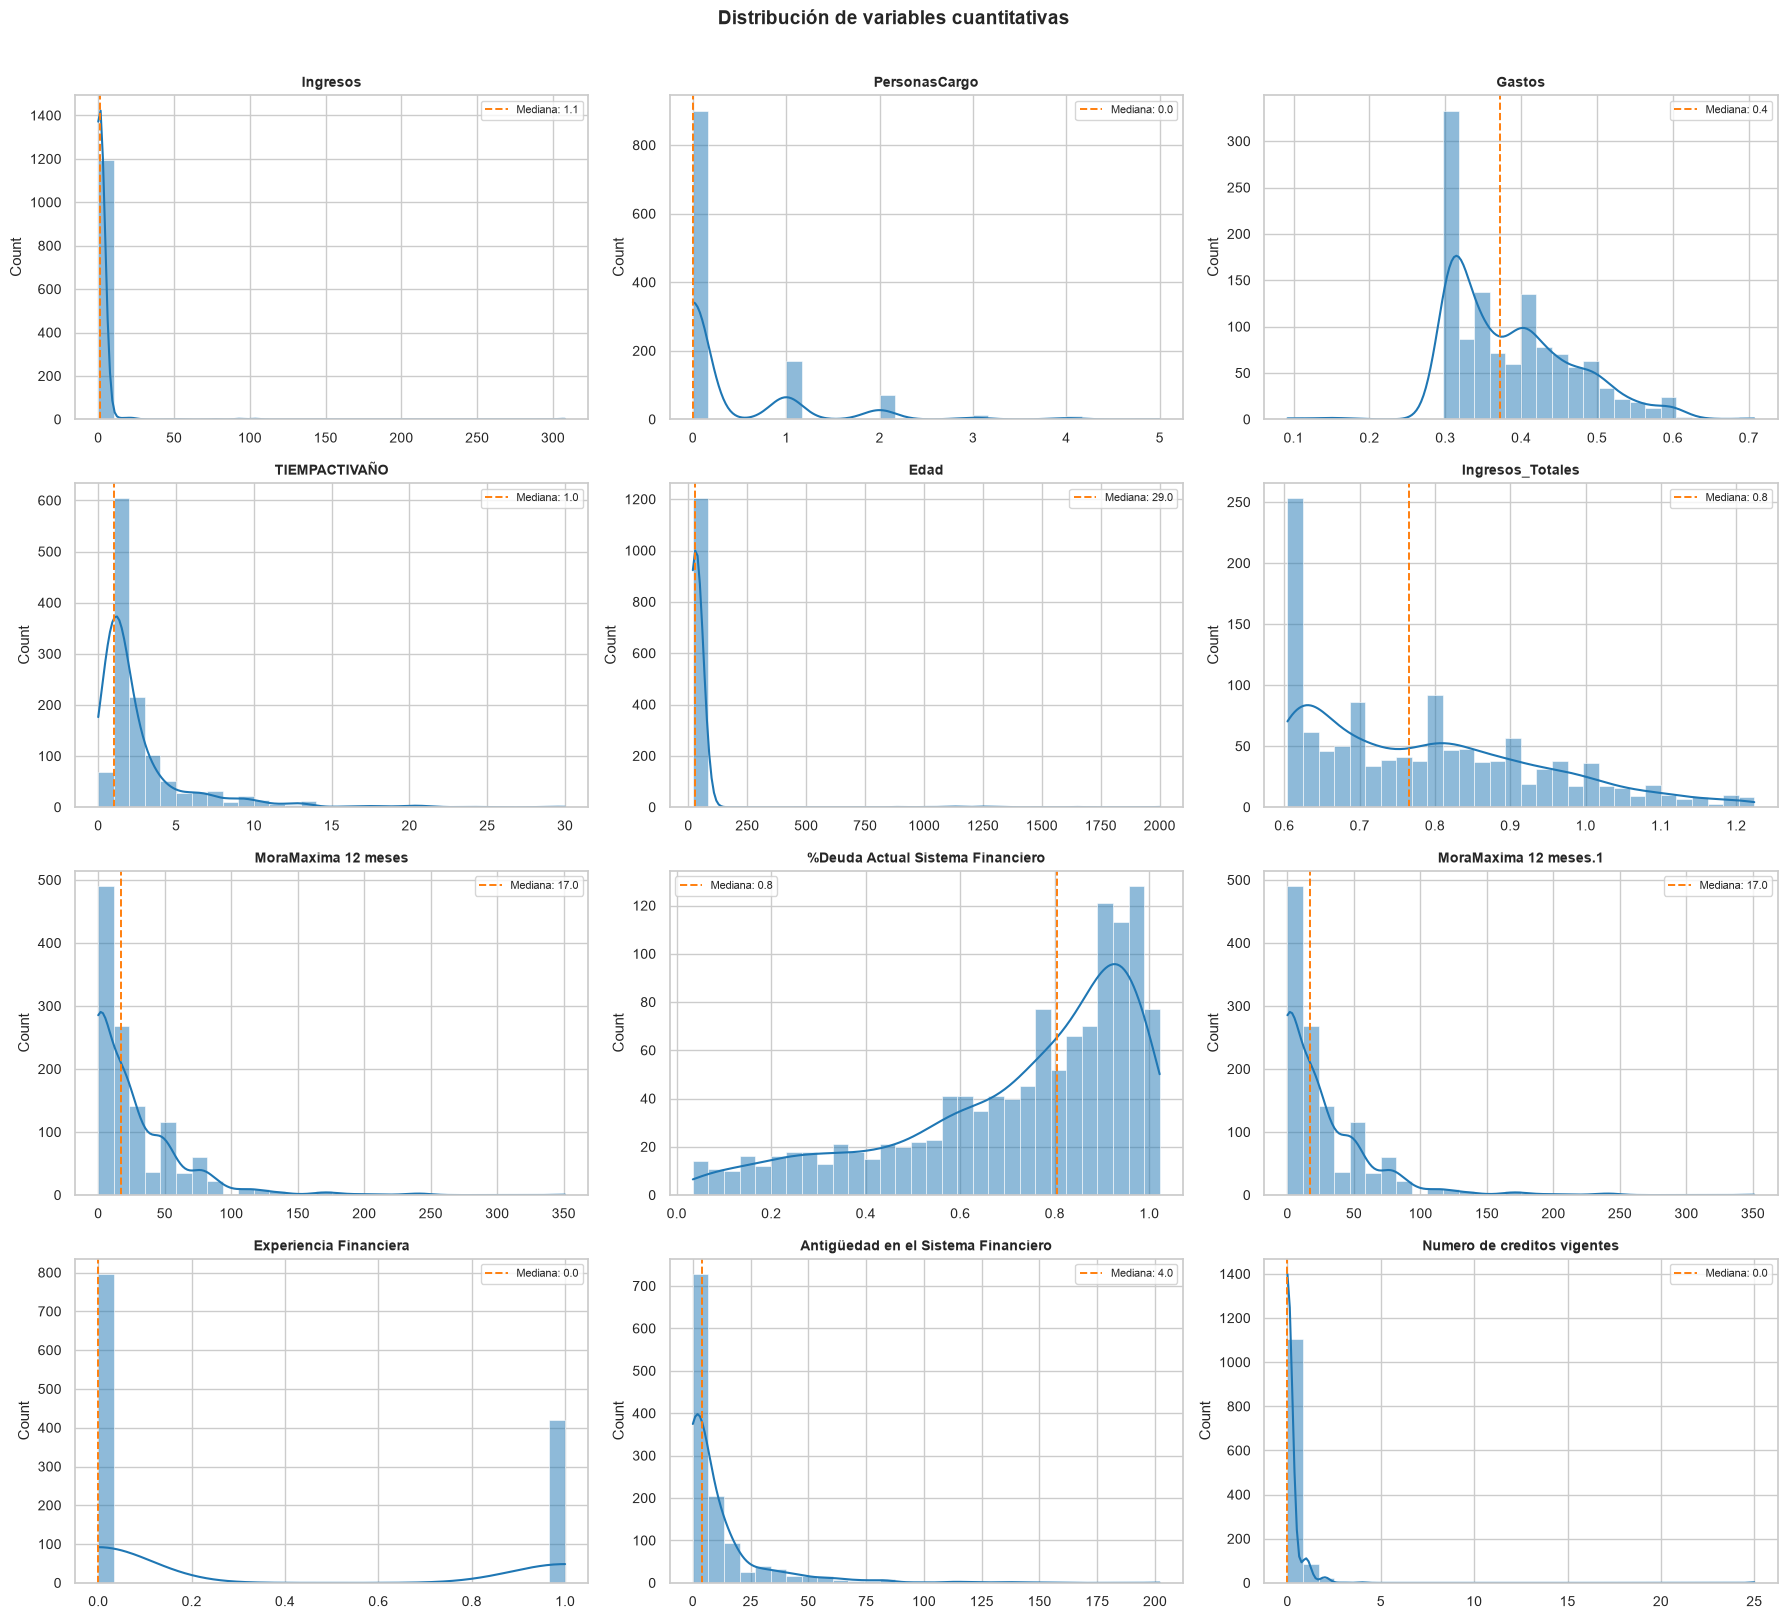

In [5]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    ax = axes[i]
    data = df[col].dropna()
    sns.histplot(data, kde=True, ax=ax, color=AZUL, bins=30, edgecolor='white', linewidth=0.4)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.axvline(data.median(), color=NARANJA, linestyle='--', linewidth=1.4, label=f'Mediana: {data.median():.1f}')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de variables cuantitativas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4.2 — Variables Cuantitativas: Boxplots (detección de outliers)


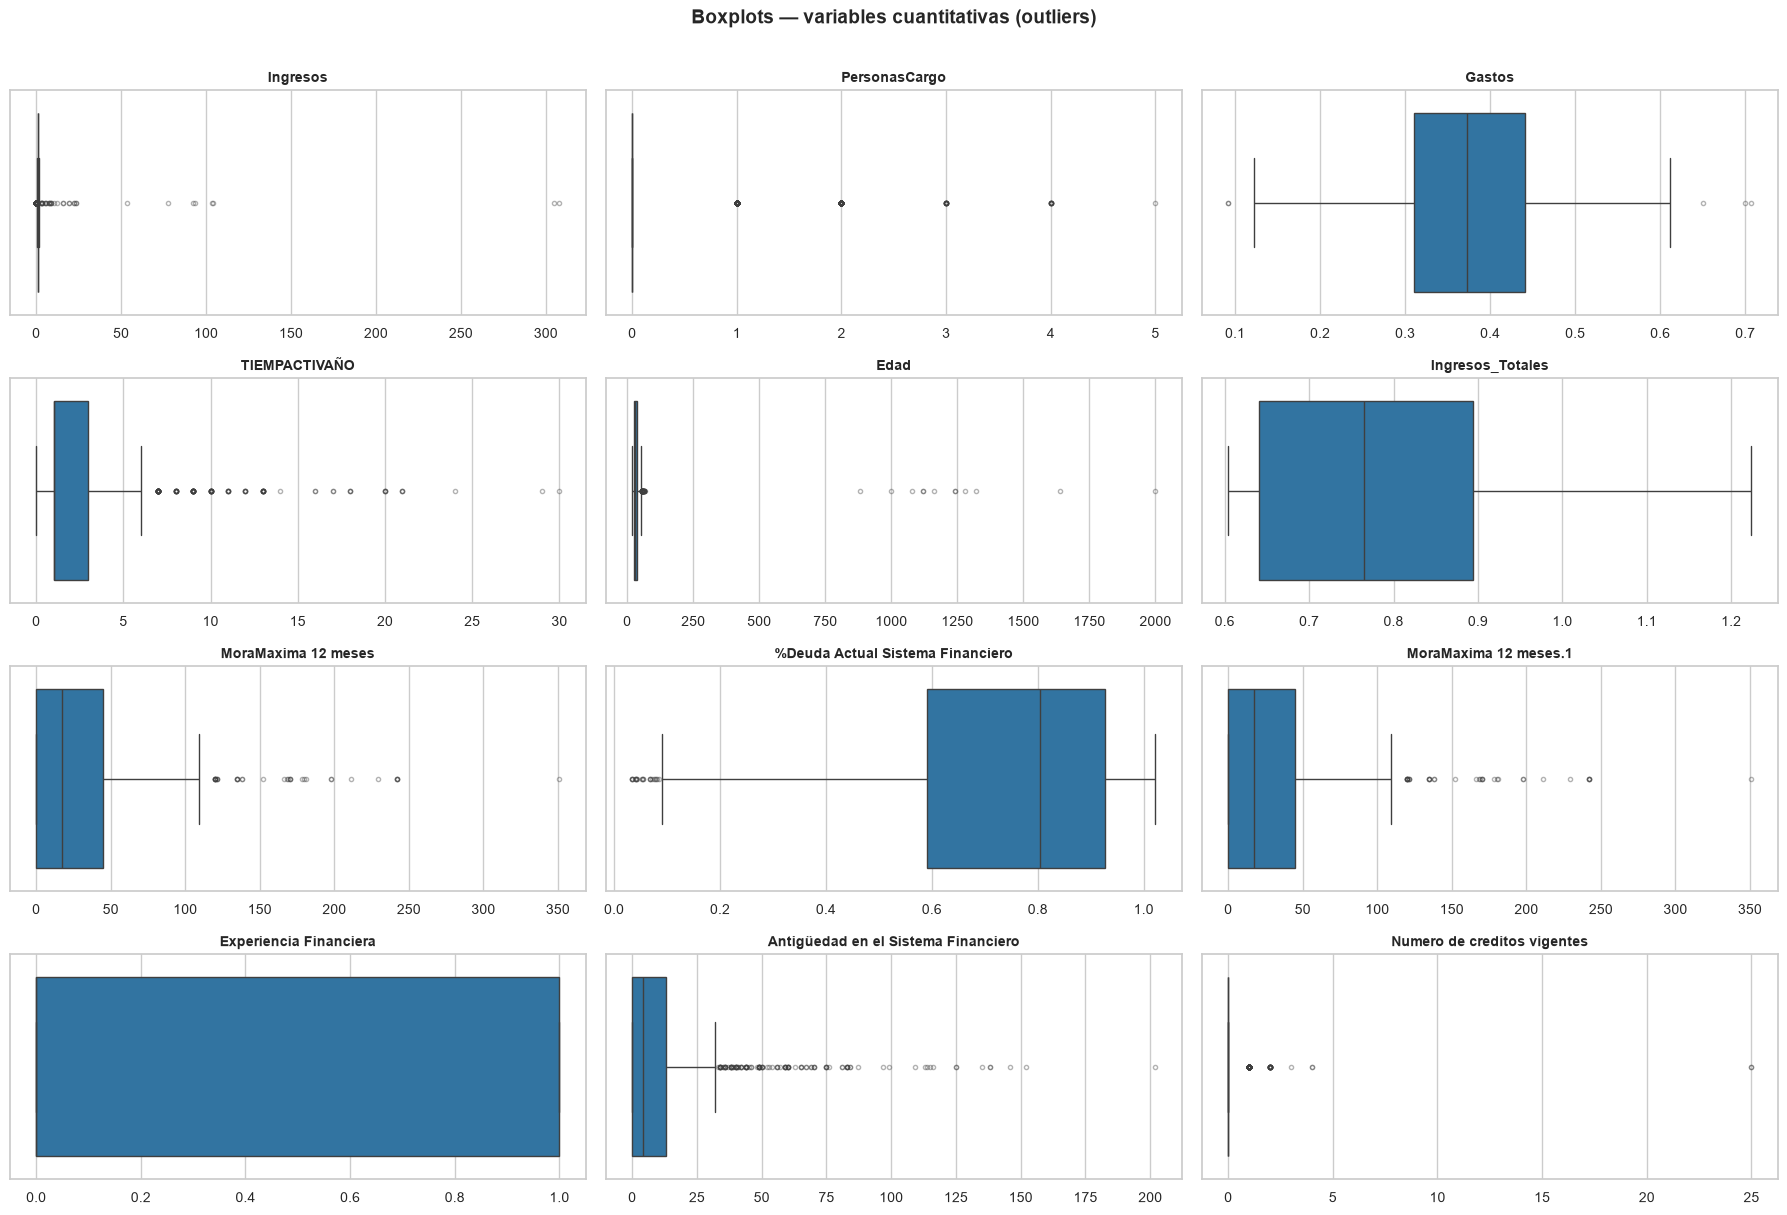

In [6]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    ax = axes[i]
    sns.boxplot(x=df[col].dropna(), ax=ax, color=AZUL, flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots — variables cuantitativas (outliers)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4.3 — Variables Cualitativas: Frecuencia de categorías


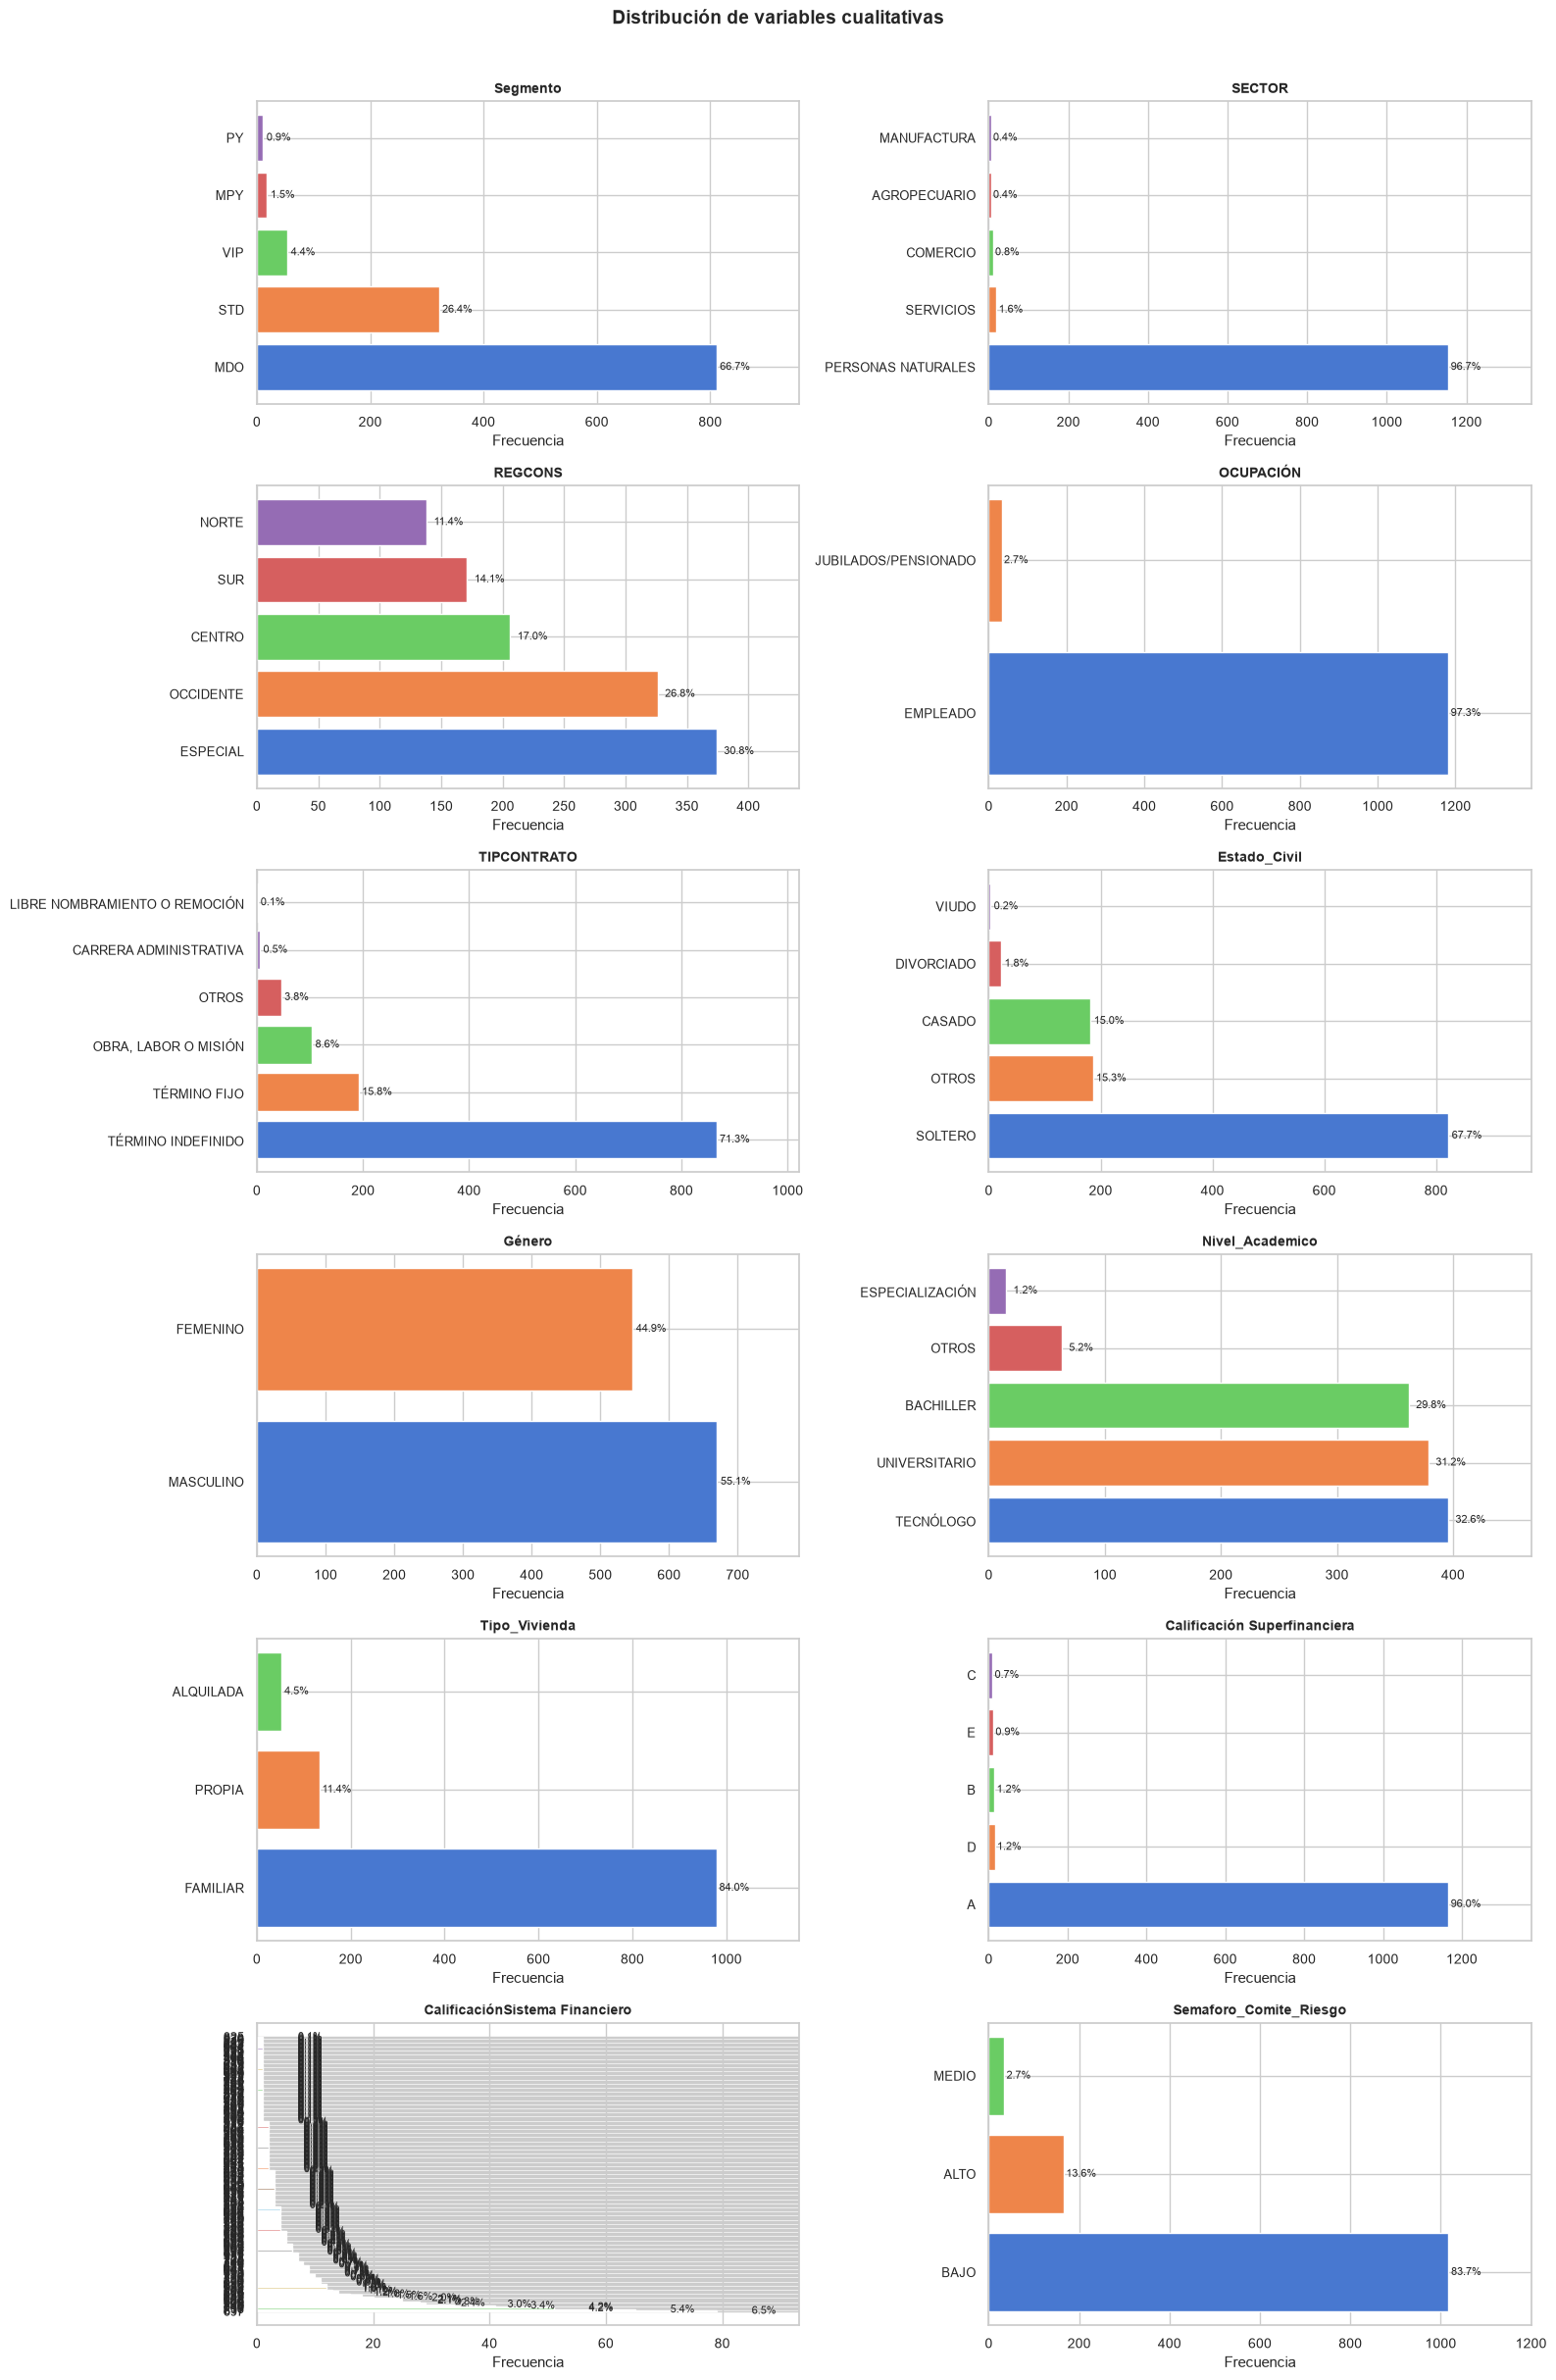

In [7]:
ncols_cat = 2
nrows_cat = int(np.ceil(len(cols_cat) / ncols_cat))
fig, axes = plt.subplots(nrows_cat, ncols_cat, figsize=(16, nrows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    ax = axes[i]
    orden = df[col].value_counts().index.tolist()
    counts = df[col].value_counts().reindex(orden)
    total_col = counts.sum()
    palette_col = sns.color_palette('muted', len(orden))
    # barh manual para máxima compatibilidad con cualquier versión de seaborn
    bars = ax.barh(range(len(orden)), counts.values, color=palette_col)
    ax.set_yticks(range(len(orden)))
    ax.set_yticklabels(orden, fontsize=9)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Frecuencia')
    for bar, val in zip(bars, counts.values):
        pct = val / total_col * 100
        ax.text(bar.get_width() + total_col * 0.005, bar.get_y() + bar.get_height() / 2,
                f'{pct:.1f}%', va='center', fontsize=8)
    ax.set_xlim(0, counts.max() * 1.18)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de variables cualitativas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4.4 — Variables objetivo: Distribución de Mora30 y Mora60


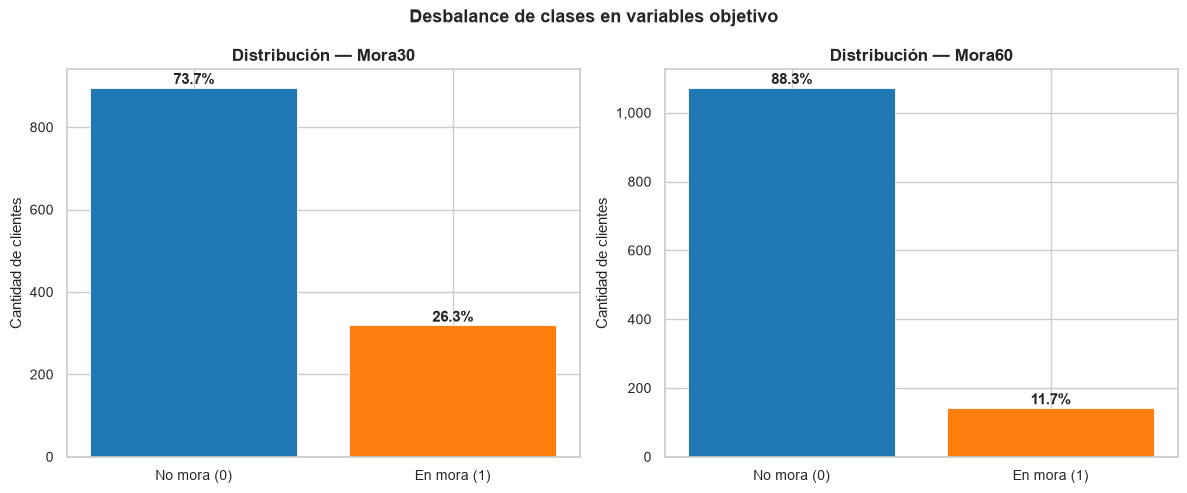


=== Balance de clases ===
  Mora30 →  No mora: 73.7%  |  En mora: 26.3%
  Mora60 →  No mora: 88.3%  |  En mora: 11.7%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, target in zip(axes, TARGETS):
    counts = df[target].value_counts().sort_index()
    pcts   = counts / counts.sum() * 100
    bars   = ax.bar(['No mora (0)', 'En mora (1)'], counts.values,
                    color=[AZUL, NARANJA], edgecolor='white', linewidth=0.6)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
                f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Distribución — {target}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cantidad de clientes')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Desbalance de clases en variables objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de balance de clases
print("\n=== Balance de clases ===")
for t in TARGETS:
    vc = df[t].value_counts(normalize=True).mul(100).round(1)
    print(f"  {t} →  No mora: {vc.get(0, 0):.1f}%  |  En mora: {vc.get(1, 0):.1f}%")


## 4.5 — Correlación entre variables cuantitativas


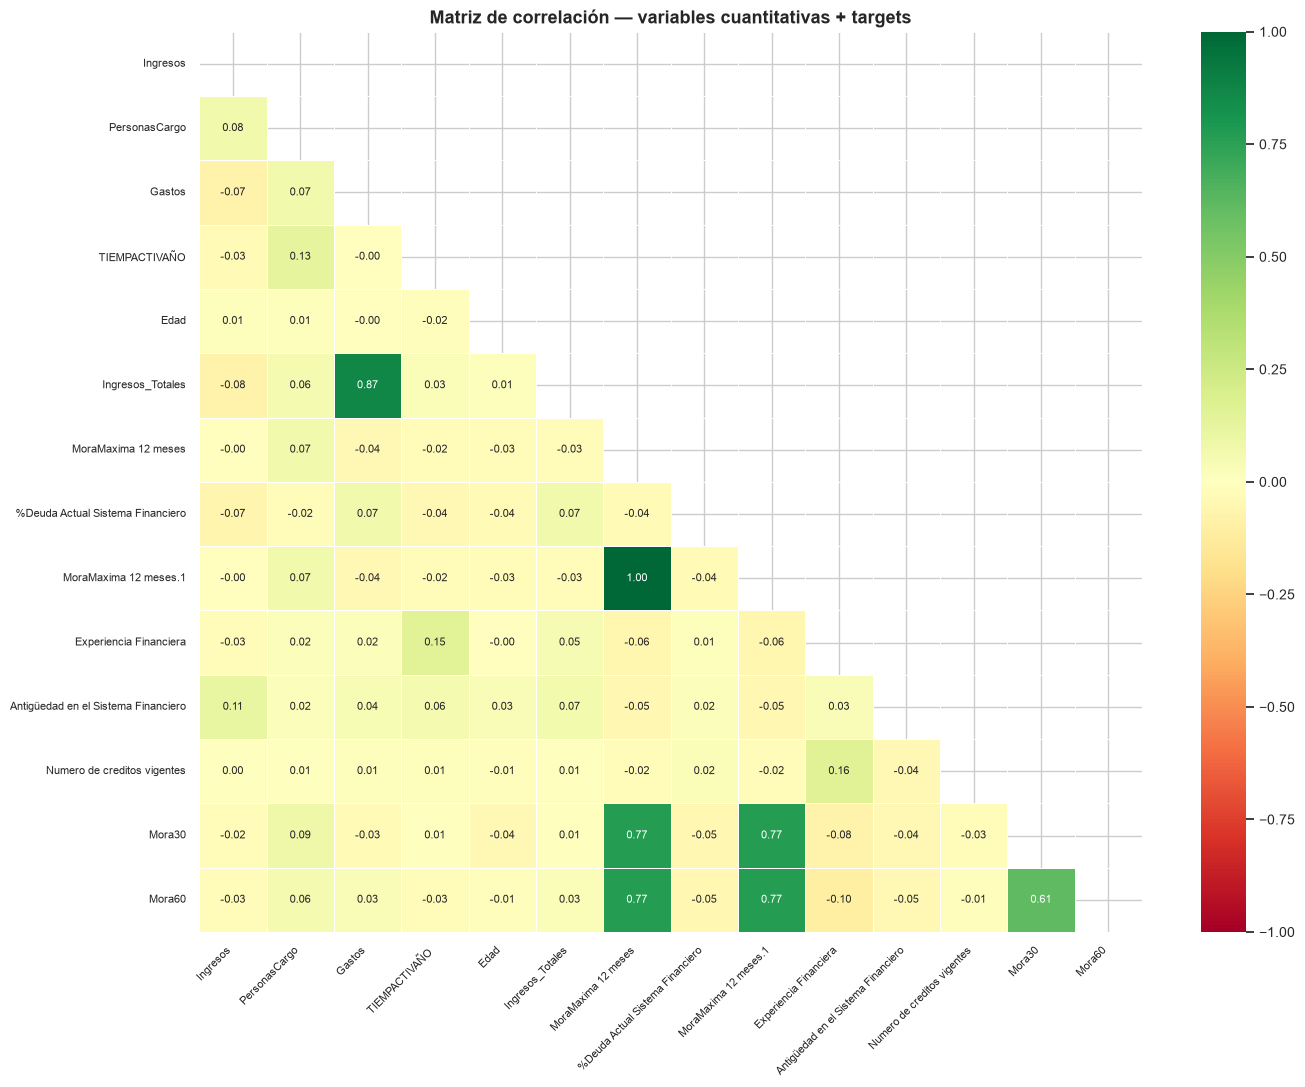

In [9]:
cols_corr = cols_num + TARGETS
corr = df[cols_corr].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # solo triángulo inferior

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.4, ax=ax,
    annot_kws={'size': 8},
    vmin=-1, vmax=1
)
ax.set_title('Matriz de correlación — variables cuantitativas + targets', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


## 4.6 — Variables cuantitativas vs. Mora30 (comparación de distribución por clase)


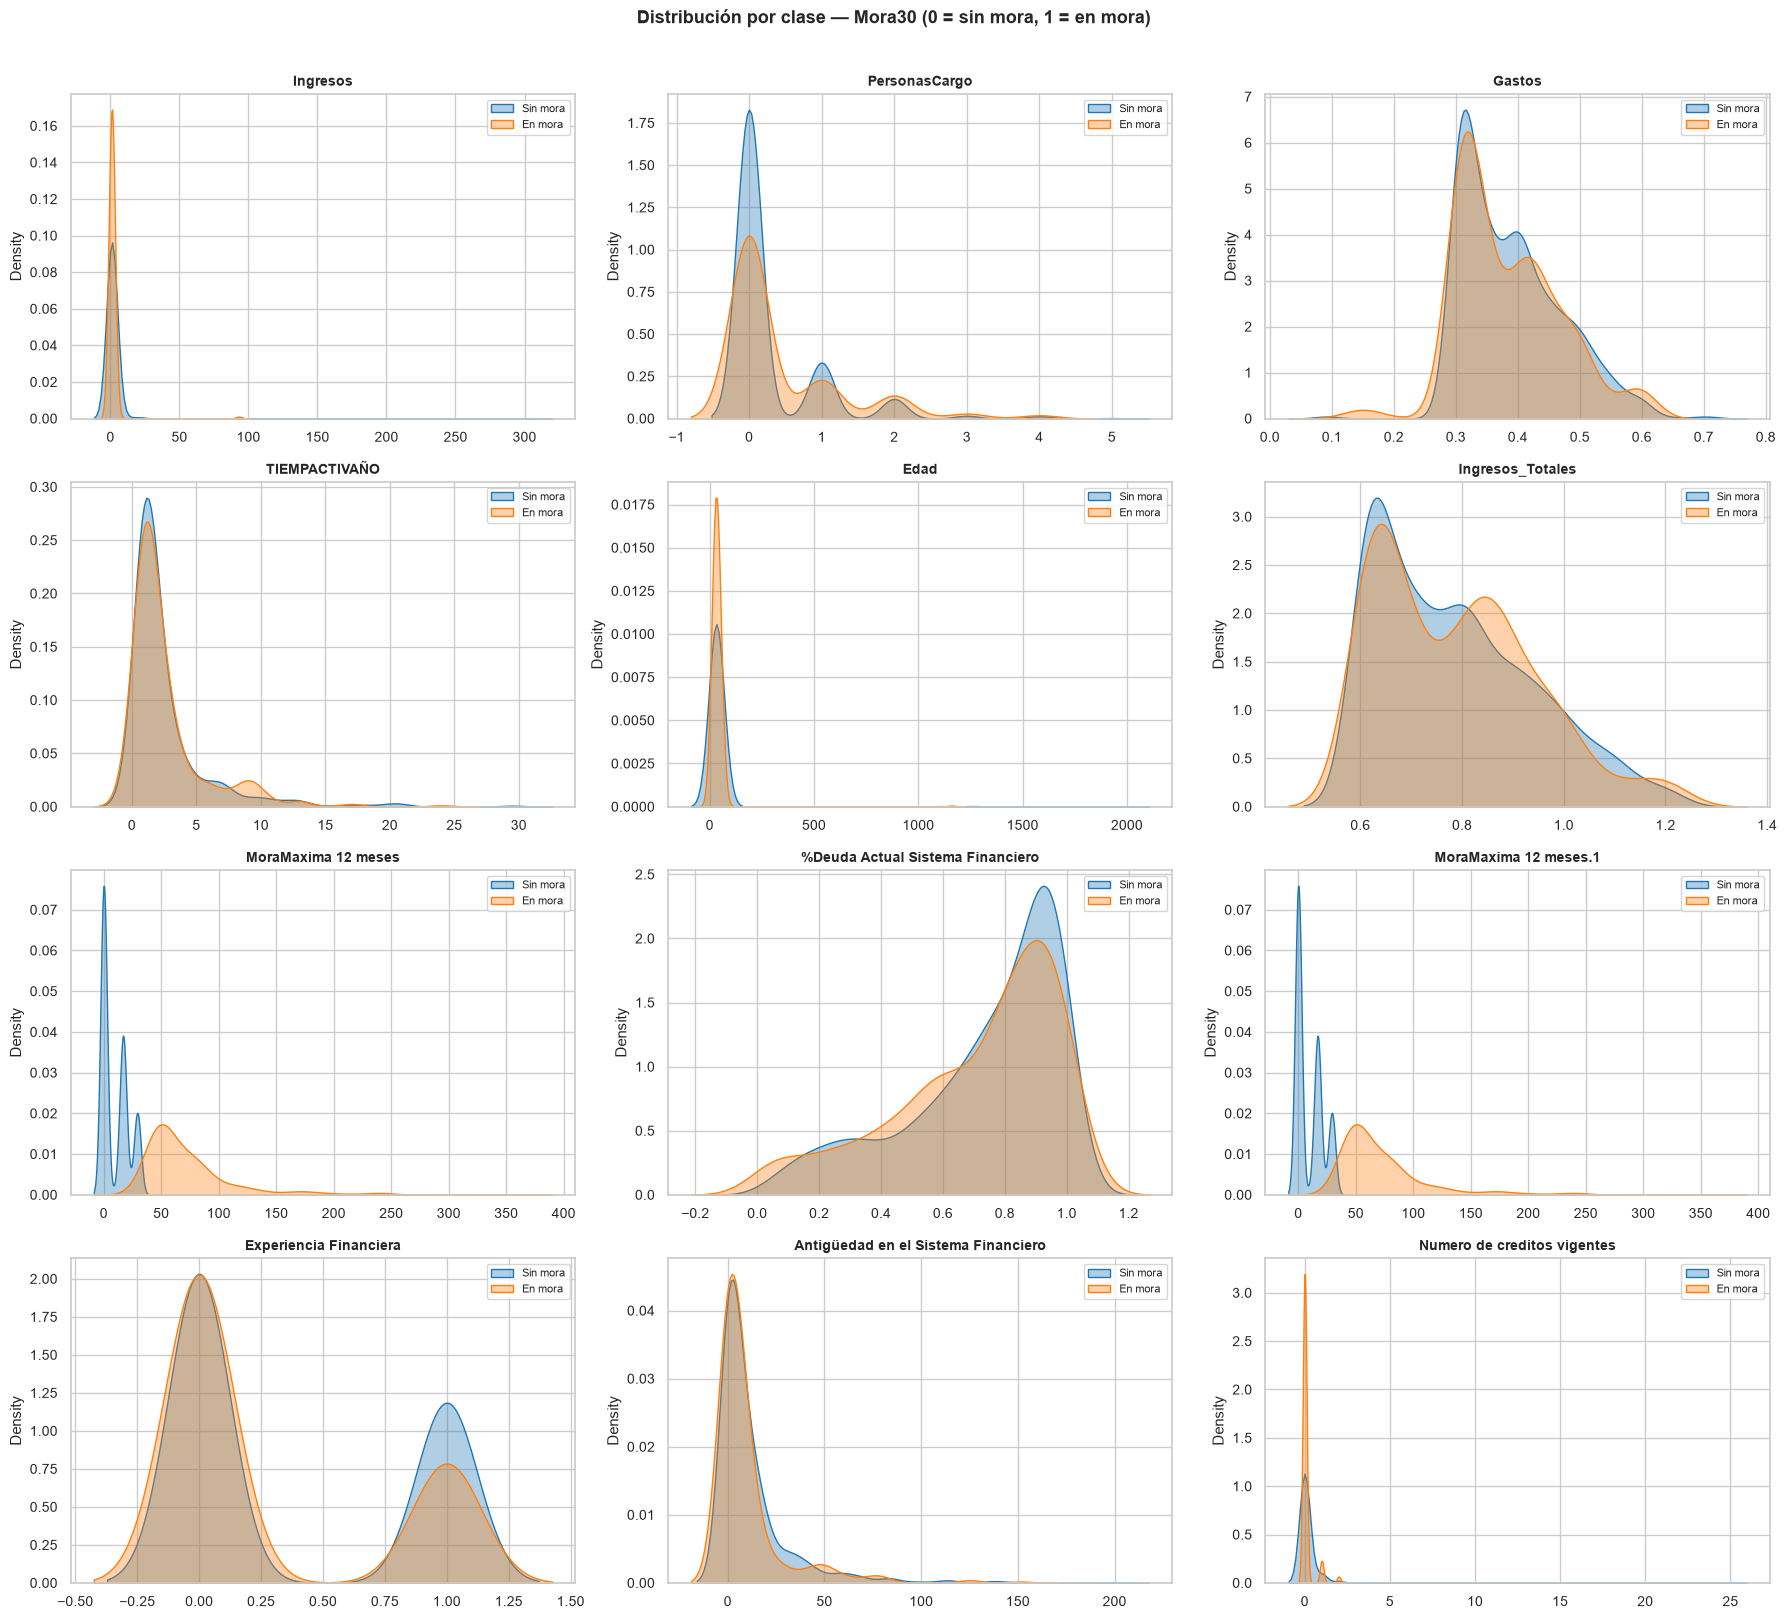

In [10]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    ax = axes[i]
    for val, color, label in [(0, AZUL, 'Sin mora'), (1, NARANJA, 'En mora')]:
        subset = df[df['Mora30'] == val][col].dropna()
        sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.35, label=label)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución por clase — Mora30 (0 = sin mora, 1 = en mora)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
